In [1]:
!pip install sentence-transformers seaborn matplotlib

In [ ]:
from sentence_transformers import SentenceTransformer, util
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
model = SentenceTransformer('all-MiniLM-L6-v2')

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

In [ ]:
sentences = [
    # Cricket
    "The batsman scored a brilliant century under pressure",
    "The bowler took a hat-trick in the final over",
    "Fielding can often change the outcome of a cricket match",
    "Jasprit Bumrah and Mitchell Starc excellent bowlers.",

    # Cooking
    "Cooking is less about strict rules and more about understanding how flavors work together.",
    "A simple dish can taste amazing if the timing and seasoning are right.",
    "Cooking is considered an art because it combines creativity, sensory engagement and technical skill to transform raw ingredients into evocative, edible masterpieces.",

    # Cyber security
    "Cyber security is all about protecting systems from threats that are constantly evolving.",
    "Even a small vulnerability can lead to serious data breaches.",
    "Effective cybersecurity ensures data confidentiality, integrity, and availability."
]

In [ ]:
embeddings = model.encode(sentences)

In [ ]:
similarity_matrix = util.cos_sim(embeddings, embeddings).numpy()

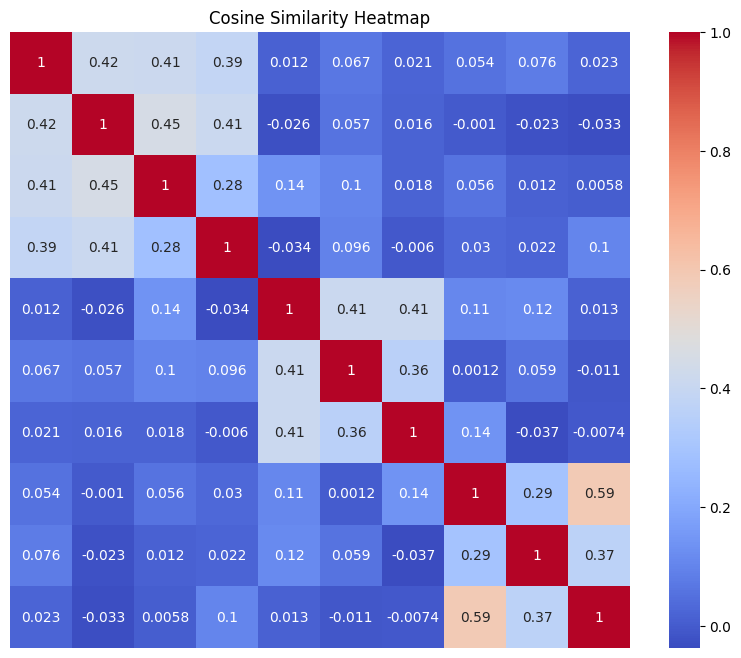

In [ ]:
plt.figure(figsize=(10, 8))
sns.heatmap(similarity_matrix, annot=True, cmap='coolwarm', xticklabels=False, yticklabels=False)
plt.title("Cosine Similarity Heatmap")
plt.show()

In [ ]:
query = "The bowler took three wickets in one over."
query_embedding = model.encode(query)

In [ ]:
hits = util.semantic_search(query_embedding, embeddings, top_k=2)[0]

In [ ]:
print("Query:", query)
print("\nTop 2 similar sentences:\n")
for hit in hits:
    print(f"Sentence: {sentences[hit['corpus_id']]}")
    print(f"Similarity Score: {hit['score']:.4f}\n")

Query: The bowler took three wickets in one over.

Top 2 similar sentences:

Sentence: The bowler took a hat-trick in the final over
Similarity Score: 0.6787

Sentence: The batsman scored a brilliant century under pressure
Similarity Score: 0.5275

